In [1]:
import numpy as np
import pickle

with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

with open('/Users/suthardr/Desktop/collection_cxta_allmice.pkl', 'rb') as file:
    collection_cxta = pickle.load(file)


In [2]:
table = collection_fc.animals['astroF6'].registration_tables['FC-A']

In [7]:
# rows where both FC and CxtA exist
valid_rows = np.where((table[:, 0] != -1) & (table[:, 1] != -1))[0]
valid_rows

array([  2,   3,  11,  15,  18,  54,  64,  93,  96, 128, 131, 148, 188,
       197, 208])

In [9]:
# collect the actual row indices for each recording
fc_idx     = table[valid_rows, 0].astype(int)
recall_idx = table[valid_rows, 1].astype(int)

array([  2,   3,  11,  15,  18,  54,  64,  94,  97, 130, 133, 150, 190,
       124,  86])

In [11]:
fc_traces = collection_fc.animals['astroF6'].accepted_traces.to_numpy().T
recall_traces = collection_cxta.animals['astroF6'].accepted_traces.to_numpy().T #this is cell x time

array([[ 6.25537515e-03,  4.38119259e-03,  2.58963499e-03, ...,
         4.82863200e-04, -1.60415113e-04, -6.86845684e-04],
       [ 8.87908337e-03,  2.36477609e-03,  2.36799341e-03, ...,
         2.44284526e-03,  2.58851377e-03, -4.14130152e-04],
       [-1.68464686e-04, -2.88565789e-03, -1.60379212e-03, ...,
         1.24261883e-03, -9.65290769e-05,  2.06093126e-03],
       ...,
       [ 4.74103098e-03,  2.87345420e-03,  2.61462175e-03, ...,
         1.58555222e-03,  1.19299547e-03,  2.60153754e-03],
       [-7.04245500e-05,  4.16570467e-03,  4.37279562e-03, ...,
         5.67436765e-03,  3.47615349e-03,  6.24146884e-04],
       [-3.13328850e-03, -6.39823830e-04, -4.21368200e-04, ...,
         5.64646680e-04,  1.76618137e-03,  2.81072777e-03]])

In [14]:
fc_active     = fc_traces[fc_idx, :]           # rows by position
recall_active = recall_traces[recall_idx, :]

In [15]:
from scipy import stats
fc_dfz = stats.zscore(fc_active, axis=1)
recall_dfz = stats.zscore(recall_active, axis=1)

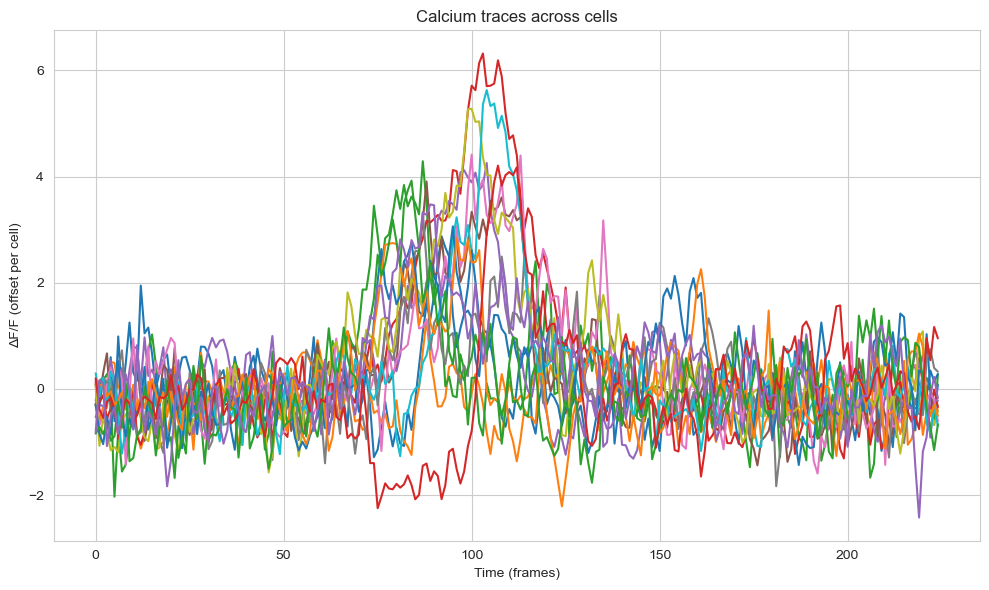

In [20]:
import matplotlib.pyplot as plt
data = fc_dfz
plt.figure(figsize=(10, 6))
for i in range(data.shape[0]):
    plt.plot(data[i, :],label=f'Cell {i}')  # offset each cell vertically
plt.xlabel('Time (frames)')
plt.ylabel('ΔF/F (offset per cell)')
plt.title('Calcium traces across cells')
plt.tight_layout()
plt.show()

In [17]:
import onep
time = collection_fc.animals['astroF6'].Timestamps.to_numpy().squeeze()

across_eta_, time_fc = onep.eta_individual_cells(
    data=fc_dfz,
    timestamps=time,
    events=[[120, 180, 240, 300]],  # detected onsets
    window=15
)

across_eta_R, time_R = onep.eta_individual_cells(
    data=recall_dfz,
    timestamps=time,
    events=[[52.866, 286.7835]],
    window=15
)
#astroM3 - 71.9448772796669, 224.9276649396253, 266.7955865787648

#astroM4-121.5068386007773, 171.4685321043864, 243.9129876846197,
       #285.4811166796225

#astroM5 - 34.67342136063298, 89.83114064325375, 173.8667238256524

#astroM6 - 84.73501601221373,  148.286278021374, 174.9658172610687,
       #266.6954690290077

#astroM7 - 43.16693610899183,  118.509227373297, 229.5241950054496,
       #266.8955702479564

#astroM8 - 91.42997888754353,133.3978380490389,248.8094507431512,  275.489018352959

#astroM9 - 67.54823800666061, 111.5145467683924, 143.0903503336361

In [ ]:
#Plot heatmap -